# Dimensionless diaphragm chain

A row of bistable diaphragms (each can sit in a "low" or "high" state) connected by
sealed gas pockets. Squeezing one pocket pushes on its neighbour through Boyle's law
(pressure x volume = constant), so a switch can travel along the row as a wave.

Written in dimensionless form, the whole model depends on just **four** numbers:

| group | what it is |
|-------|------------|
| $\eta = \frac{A p_0}{k a^3}$   | gas pressure vs. how stiff each diaphragm is |
| $\theta = \frac{A a}{V_0}$ | how much a gas pocket's volume changes when a diaphragm switches |
| $\Pi = \frac{\delta}{a^3}$    | how lopsided the two states are - this is what drives the wave |
| $\Omega = \frac{\alpha}{a\sqrt{mk}}$ | damping |

The dimensional notebook already mapped what the raw knobs ($A, \delta, \alpha$) do one
at a time. This notebook is about the things you can only see with the dimensionless groups:

- **same groups means same wave** - two builds with completely different raw numbers behave identically
- **different knobs, one curve** - sweeping $p_0, V_0 \,\text{or}\, A$ is secretly the same sweep
- **width is set by one product** - $\eta$ and $\theta$ only ever act through $\eta \, \theta$
- **a validity map for the wave-speed formula** - the 10% bounds asked once, in group form, for every build
- **a spring-vs-gas check** - at fixed $\eta \, \theta$, mirrored waves pick up a small speed difference that a spring chain cannot have

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# the four dimensionless groups (canonical values)
eta   = 80.0    # gas pressure / diaphragm stiffness
theta = 0.1     # volume change per switch
Pi    = 0.115   # asymmetry between the two states (drives the wave)
Omega = 10.0    # damping

In [2]:
def wells(Pi):
    """The three rest states: roots of  u^3 - u + Pi = 0,  sorted low < mid < high."""
    r = np.sort(np.roots([1, 0, -1, Pi]).real)
    return r[0], r[1], r[2]

def gas_force(u, eta, theta):
    """Boyle-law pressure force on each diaphragm."""
    p = 1.0 / (1.0 + theta * (u[1:] - u[:-1]))     # 1 / volume of each gas pocket
    F = np.zeros_like(u)
    F[1:-1] = eta * (p[:-1] - p[1:])
    return F

def energy(u, v, eta, theta, Pi):
    """Total energy: motion + the double-well + the gas."""
    gaps = 1.0 + theta * (u[1:] - u[:-1])
    well = u**4/4 - u**2/2 + Pi*u
    return 0.5*np.sum(v**2) + np.sum(well) - (eta/theta)*np.sum(np.log(gaps))

def front_speed(frames, times, u_lo, u_hi, flip=False):
    """Track where the wave front is in each frame and fit its speed."""
    N = frames.shape[1]
    mid = 0.5*(u_lo + u_hi)
    pos = []
    for f in frames:
        sel = np.where(f < mid)[0] if not flip else np.where(f > mid)[0]
        if len(sel) == 0:
            pos.append(0.0)
        elif sel[-1] + 1 >= N:
            pos.append(float(sel[-1]))
        else:
            i = sel[-1]
            pos.append(i + (f[i] - mid) / (f[i] - f[i+1]))   # sub-diaphragm crossing
    pos = np.array(pos)
    half = times > 0.5*times[-1]                             # steady half only
    return (np.polyfit(times[half], pos[half], 1)[0] if half.sum() > 2 else np.nan), pos

def run(eta, theta, Pi, Omega, N=120, T=150.0, dt=None,
        n_sponge=10, sponge=4.0, n_trigger=5, save_every=200,
        track_energy=False, flip=False):
    """
    Integrate the chain and return the wave.

    Normally the left end is held low and the rest starts high; the boundary travels
    right as a wave. With flip=True the roles swap (left end high, rest low), which
    runs the mirrored wave. Returns a dict with frames, times, wave position and
    speed, or {'error': ...} if a gas pocket collapses.
    """
    if dt is None:
        dt = 0.05 / max(np.sqrt(2 + 4*abs(eta*theta)), Omega)
    u_lo, _, u_hi = wells(Pi)
    bg, trig = (u_hi, u_lo) if not flip else (u_lo, u_hi)

    # a little extra damping near the walls so the wave is absorbed, not reflected
    damp = np.full(N, float(Omega))
    if n_sponge > 0:
        ramp = sponge * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, bg); u[:n_trigger] = trig
    v = np.zeros(N)
    force = lambda uu: gas_force(uu, eta, theta) - (uu**3 - uu + Pi)

    steps = int(T / dt)
    frames, E = [], []
    a = force(u) - damp*v
    for step in range(steps):
        u += v*dt + 0.5*a*dt**2
        u[:n_trigger] = trig; u[-1] = bg
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        if step > steps//10 and np.min(1 + theta*(u[1:]-u[:-1])) <= 0:
            return {'error': 'a gas pocket collapsed to zero volume'}
        f = force(u)
        v = (v + 0.5*dt*(a + f)) / (1 + 0.5*damp*dt)   # semi-implicit, handles damping
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a = f - damp*v
        if step % save_every == 0:
            frames.append(u.copy())
            if track_energy: E.append(energy(u, v, eta, theta, Pi))

    frames = np.array(frames)
    times  = np.arange(len(frames)) * save_every * dt
    speed, pos = front_speed(frames, times, u_lo, u_hi, flip=flip)

    out = {'frames': frames, 'times': times, 'pos': pos, 'speed': speed,
           'u_lo': u_lo, 'u_hi': u_hi}
    if track_energy: out['energy'] = np.array(E)
    return out

## A travelling wave

Hold the left end low and the right end high. The boundary between them moves along
the chain as a switching wave. Below it is shown at four moments in time. This is simply verifying what was shown in the dimensional notebook already.

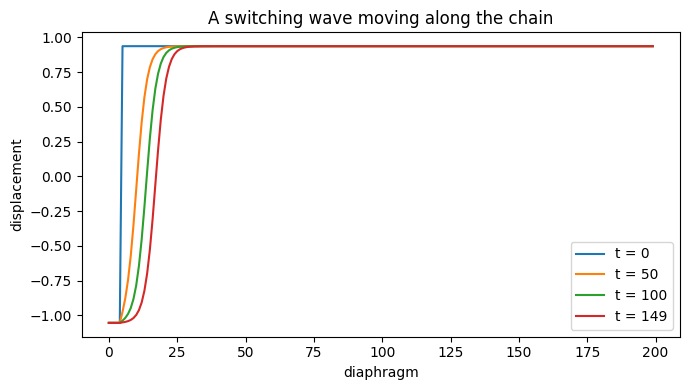

wave speed: 0.069 diaphragms per unit time


In [3]:
r = run(eta, theta, Pi, Omega, N=200, T=150)
sites = np.arange(r['frames'].shape[1])

plt.figure(figsize=(7, 4))
idx = [0, len(r['frames'])//3, 2*len(r['frames'])//3, len(r['frames'])-1]
for i in idx:
    plt.plot(sites, r['frames'][i], label=f"t = {r['times'][i]:.0f}")
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('A switching wave moving along the chain')
plt.legend(); plt.tight_layout(); plt.show()

print(f"wave speed: {r['speed']:.3f} diaphragms per unit time")

## Same groups, same wave

Build two completely different physical systems - different masses, stiffnesses and
pressures - but chosen to share the same four non-dimensional groups by scaling choices. They produce the
exact same wave. This is the foundation everything else rests on.

  system A:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
  system B:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
biggest difference between the three runs: 1.0e-14


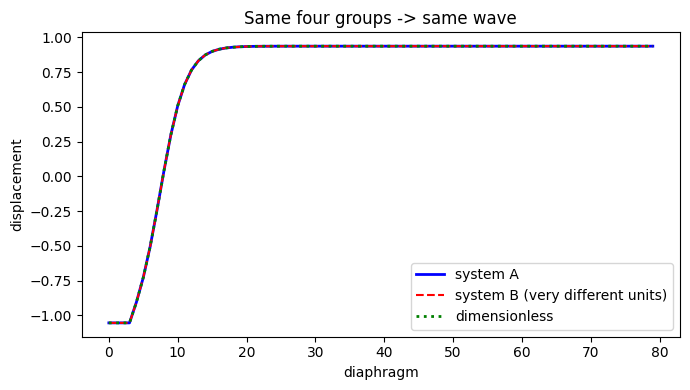

In [4]:
def dimensional_from_groups(eta, theta, Pi, Omega, m, k, a, A):
    """Physical parameters that reproduce the four groups (m, k, a, A are free choices)."""
    return dict(m=m, k=k, a=a, A=A,
                p0=eta*k*a**3/A, V0=A*a/theta, delta=Pi*a**3, alpha=Omega*a*np.sqrt(m*k))

def groups_from_dimensional(p):
    """Go the other way: recover (eta, theta, Pi, Omega) from physical parameters."""
    return (p['A']*p['p0']/(p['k']*p['a']**3), p['A']*p['a']/p['V0'],
            p['delta']/p['a']**3, p['alpha']/(p['a']*np.sqrt(p['m']*p['k'])))

def run_dimensional(m, A, k, p0, V0, a, delta, alpha,
                    N=80, T=60.0, dt_tilde=None, n_sponge=6, sponge=4.0,
                    n_trigger=4, save_every=100):
    """The same simulation in raw physical units. Returns (times, frames) with the
    output already rescaled, or None if a gas pocket collapses."""
    eta_ = A*p0/(k*a**3)
    Omega_ = alpha/(a*np.sqrt(m*k))
    if dt_tilde is None:
        dt_tilde = 0.05 / max(np.sqrt(2 + 4*abs(eta_*A*a/V0)), Omega_)
    T_scale = np.sqrt(m/(k*a**2))
    dt = dt_tilde * T_scale
    u_lo, _, u_hi = np.sort(np.roots([1, 0, -a**2, delta]).real)

    damp = np.full(N, float(alpha))
    if n_sponge > 0:
        ramp = sponge * a*np.sqrt(m*k) * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, u_hi); u[:n_trigger] = u_lo
    v = np.zeros(N)
    def force(uu):
        pr = p0*V0 / (V0 + A*(uu[1:] - uu[:-1]))
        F = np.zeros_like(uu); F[1:-1] = A*(pr[:-1] - pr[1:])
        return F - k*(uu**3 - a**2*uu + delta)

    steps = int(T*T_scale / dt)
    hist, acc = [], (force(u) - damp*v) / m
    for step in range(steps):
        u += v*dt + 0.5*acc*dt**2
        u[:n_trigger] = u_lo; u[-1] = u_hi; v[:n_trigger] = 0; v[-1] = 0
        if step > steps//10 and np.min(V0 + A*(u[1:] - u[:-1])) <= 0:
            return None                                    # pocket collapsed
        f = force(u)
        v = (v + 0.5*dt*(acc + f/m)) / (1 + 0.5*damp*dt/m)
        v[:n_trigger] = 0; v[-1] = 0
        acc = (f - damp*v) / m
        if step % save_every == 0:
            hist.append(u / a)              # divide by length scale -> same units as run()
    return np.arange(len(hist)) * save_every * dt_tilde, np.array(hist)

# two genuinely different physical builds, both tuned to the same four groups
A_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=1.0,  k=1.0,   a=1.0,  A=1.0)
B_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=3e-3, k=250.0, a=0.02, A=5e-4)

for name, p in [('system A', A_sys), ('system B', B_sys)]:
    e, t, pi, om = groups_from_dimensional(p)
    print(f"  {name}:  eta={e:.2f}   theta={t:.3f}   Pi={pi:.4f}   Omega={om:.3f}")

# run both physical systems and the dimensionless one; they should coincide
dt0 = 0.05 / max(np.sqrt(2 + 4*eta*theta), Omega)
kw  = dict(N=80, T=60.0, dt_tilde=dt0, n_sponge=6, n_trigger=4, save_every=100)
tA, hA = run_dimensional(**A_sys, **kw)
tB, hB = run_dimensional(**B_sys, **kw)
hD = run(eta, theta, Pi, Omega, N=80, T=60.0, dt=dt0,
         n_sponge=6, n_trigger=4, save_every=100)['frames']

n    = min(len(hA), len(hB), len(hD))
diff = max(np.max(np.abs(hA[:n]-hB[:n])), np.max(np.abs(hA[:n]-hD[:n])))
print(f"biggest difference between the three runs: {diff:.1e}")

mid = n // 2
plt.figure(figsize=(7, 4))
plt.plot(hA[mid], 'b-',  lw=2,   label='system A')
plt.plot(hB[mid], 'r--', lw=1.5, label='system B (very different units)')
plt.plot(hD[mid], 'g:',  lw=2,   label='dimensionless')
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('Same four groups -> same wave'); plt.legend(); plt.tight_layout(); plt.show()

## Check: the simulation is sound

Turn the damping off ($\Omega = 0$). With no damping the total energy should stay flat -
a basic check that the integrator is behaving and not quietly adding or losing energy.

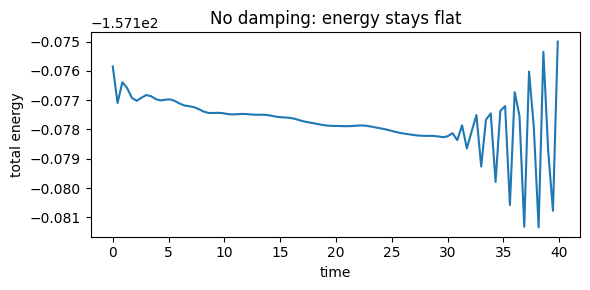

largest energy drift: 3.5e-05


In [5]:
r0 = run(eta, theta, Pi, 0.0, N=80, T=40, n_sponge=0, n_trigger=4,
         save_every=50, track_energy=True)
E = r0['energy']
drift = np.max(np.abs((E - E[0]) / abs(E[0])))

plt.figure(figsize=(6, 3))
plt.plot(r0['times'][:len(E)], E)
plt.xlabel('time'); plt.ylabel('total energy')
plt.title('No damping: energy stays flat'); plt.tight_layout(); plt.show()

print(f"largest energy drift: {drift:.1e}")

## Different knobs, one curve

In raw units there look to be many independent ways to change the wave: pump up
the gas pressure $p_0$, shrink the gas pockets $V_0$, enlarge the diaphragm area $A$.
Three separate experiments - one knob each, nothing else adjusted - and they do
not even share an x-axis: one is in pressure units, one in volume units, one in
area units. There is no way to draw them on a single plot in raw terms.

The groups say all three knobs act on the wave through one number: the coupling
$\eta \, \theta$, which in raw terms is $A^2 p_0 / k V_0 a^2$ - every one of those knobs
lives inside it. $\eta \, \theta$ is the shared axis that raw units cannot provide:
plotted against it, the three experiments become one curve.

The collapse is good to a few percent, and the small leftover spread is not
noise: it tracks $\theta$, the one group the product does not capture - a small
effect checked directly at the end of the notebook.

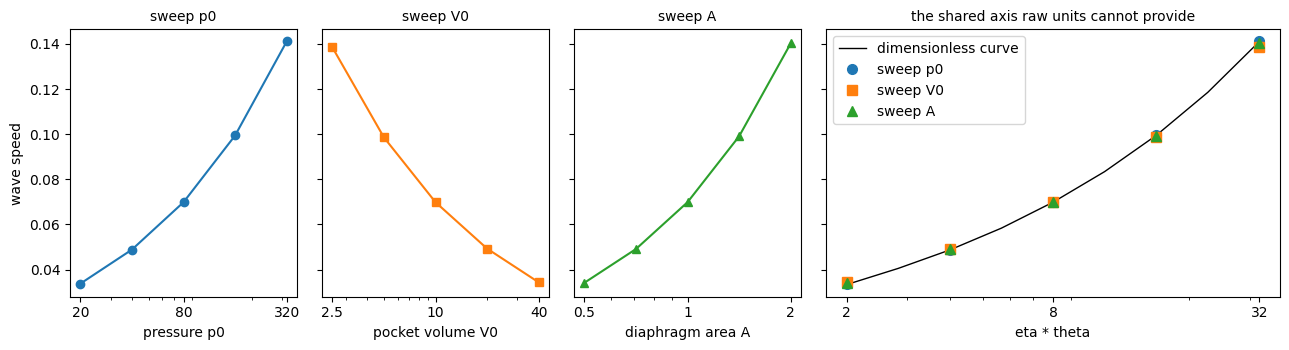

In [11]:
# Three experiments in raw units, one knob each, no compensating adjustments:
#   turn up the pressure p0        (moves eta only)
#   shrink the gas pockets V0      (moves theta only)
#   enlarge the diaphragm area A   (moves eta and theta together)
# Their x-axes are different physical quantities - the groups must supply a shared one.
M = np.array([0.25, 0.5, 1, 2, 4])                  # knob multipliers
base = dict(m=1, k=1, a=1, delta=Pi, alpha=Omega)   # unit scales

u_lo0, _, u_hi0 = wells(Pi)
def dim_speed(**build):
    """Wave speed of one raw physical build."""
    t, h = run_dimensional(**build, N=100, T=100)
    return front_speed(h, t, u_lo0, u_hi0)[0]

sweeps = [  # (title, x in raw units, x label, eta*theta, speeds, colour, marker)
    ('sweep p0', 80*M,       'pressure p0',      8*M,
     [dim_speed(A=1, p0=80*m, V0=10, **base) for m in M], 'tab:blue',   'o'),
    ('sweep V0', 10/M,       'pocket volume V0', 8*M,
     [dim_speed(A=1, p0=80, V0=10/m, **base) for m in M], 'tab:orange', 's'),
    ('sweep A',  np.sqrt(M), 'diaphragm area A', 8*M,
     [dim_speed(A=np.sqrt(m), p0=80, V0=10, **base) for m in M], 'tab:green', '^'),
]

# the one dimensionless curve, at the canonical theta
et_grid  = np.geomspace(2, 32, 9)
master_c = [run(et/theta, theta, Pi, Omega, N=100, T=100)['speed'] for et in et_grid]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True,
                         gridspec_kw={'width_ratios': [1, 1, 1, 2]})
for ax, (title, x, xlab, et, v, col, mk) in zip(axes[:3], sweeps):
    ax.plot(x, v, mk + '-', color=col)
    ax.set_xscale('log'); ax.set_xlabel(xlab)
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel('wave speed')

ax4 = axes[3]
ax4.plot(et_grid, master_c, 'k-', lw=1, label='dimensionless curve')
for title, x, xlab, et, v, col, mk in sweeps:
    ax4.plot(et, v, mk, ms=7, color=col, label=title)
ax4.set_xscale('log'); ax4.set_xlabel('eta * theta')
ax4.set_title('the shared axis raw units cannot provide', fontsize=10)
ax4.legend()

# plain-number ticks at the actual sweep spacings instead of 10^n labels
for ax, ticks in zip(axes, [[20, 80, 320], [2.5, 10, 40], [0.5, 1, 2], [2, 8, 32]]):
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:g}' for t in ticks])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
plt.tight_layout(); plt.show()

## The pair $(\eta\theta,\ \theta)$, and where the front width comes from

Write $\Delta_n = \tilde u_{n+1} - \tilde u_n$ for the strain of pocket $n$, so its
volume is $\tilde V_n = 1 + \theta \Delta_n$. The gas force on diaphragm $n$ is

$$F_n \;=\; \eta\left[\frac{1}{\tilde V_{n-1}} - \frac{1}{\tilde V_n}\right]
      \;=\; \frac{\eta\,\theta\,\left(\Delta_n - \Delta_{n-1}\right)}{\tilde V_{n-1}\,\tilde V_n},$$

which is exact — nothing expanded, just the two fractions over a common denominator.
Since $\Delta_n - \Delta_{n-1} = \tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}$ is the
discrete Laplacian, the force factorises as

$$F_n \;=\; \underbrace{\eta\theta}_{\text{spring stiffness}}
\;\times\; \underbrace{\left(\tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}\right)}_{\text{spring-chain force}}
\;\times\; \underbrace{\frac{1}{\tilde V_{n-1}\tilde V_n}}_{\substack{\text{Boyle correction}\\ \text{depends on }\theta\text{ only}}}.$$

Three things follow:

1. **$\eta$ never appears alone.** A uniform baseline pressure pushes equally on both
   faces of a diaphragm and cancels; only pressure *differences* act, and those are
   created by volume changes, which cost one factor of $\theta$ per unit of
   displacement. Every $\eta$ therefore rides on at least one $\theta$: the gas enters
   the dynamics only through the pair $(\eta\theta,\ \theta)$.

2. **The wide-front limit.** When the fractional volume changes $|\theta\Delta_n|$ are
   small, the correction factor is $\approx 1$ and the gas is exactly a spring chain of
   stiffness $\eta\theta$. This is the limit that sets the front width, worked out next.

3. **The gas-ness lives in the denominator.** $\tilde V_{n-1}\tilde V_n$ is $<1$ for
   squeezed pockets (force enhanced) and $>1$ for stretched ones (force reduced) — the
   squeeze/stretch difference, read directly off the same identity. Its size is set by
   $B = \theta\,|\Delta|_{\max}$, the peak fractional volume change.

**The width.** In the spring limit of point 2, the width is a competition: the springs
penalise differences between neighbours, so they want to smear the front out; the
double well penalises sitting between the two states, so it wants each diaphragm to
commit. Balancing the two,

$$\eta\theta\, u'' = u^3 - u,$$

is solved exactly by $u = \tanh(x/w)$ with

$$w = \sqrt{2\,\eta\theta}.$$

Stronger coupling, wider front; deeper commitment, sharper front; they settle at the
square root.


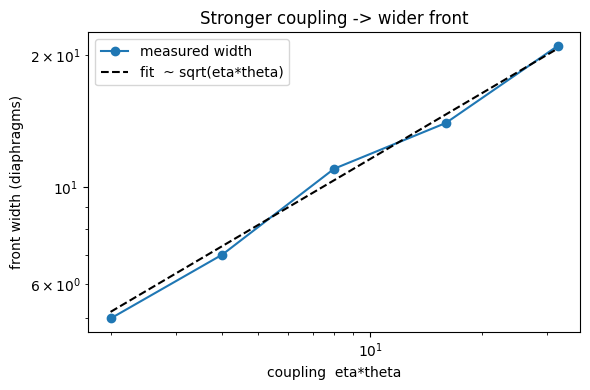

eta*theta =  2   ->   width = 5 diaphragms
eta*theta =  4   ->   width = 7 diaphragms
eta*theta =  8   ->   width = 11 diaphragms
eta*theta = 16   ->   width = 14 diaphragms
eta*theta = 32   ->   width = 21 diaphragms


In [7]:
def kink_width(frame, u_lo, u_hi):
    """Number of diaphragms caught mid-switch (between the two states)."""
    eps    = 0.05 * (u_hi - u_lo)
    inside = (frame > u_lo + eps) & (frame < u_hi - eps)
    c = int(np.argmax(np.abs(np.gradient(frame))))       # steepest point
    l = c
    while l > 0 and inside[l-1]: l -= 1
    r = c
    while r < len(frame)-1 and inside[r+1]: r += 1
    return r - l + 1

theta_w = 0.05                                            # small theta, cleaner fronts
couplings, widths = [2, 4, 8, 16, 32], []
for kap in couplings:
    r = run(kap/theta_w, theta_w, Pi, 15.0, N=200, T=120,
            n_sponge=12, sponge=8, n_trigger=5, save_every=300)
    frame = r['frames'][len(r['frames'])//2]
    widths.append(kink_width(frame, r['u_lo'], r['u_hi']))

kap = np.array(couplings, float); w = np.array(widths, float)
c   = np.sum(w * np.sqrt(kap)) / np.sum(kap)              # fit  width = c*sqrt(eta*theta)

plt.figure(figsize=(6, 4))
plt.plot(kap, w, 'o-', label='measured width')
plt.plot(kap, c*np.sqrt(kap), 'k--', label='fit  ~ sqrt(eta*theta)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('coupling  eta*theta'); plt.ylabel('front width (diaphragms)')
plt.title('Stronger coupling -> wider front'); plt.legend(); plt.tight_layout(); plt.show()

for k_, wi in zip(couplings, widths):
    print(f"eta*theta = {k_:2d}   ->   width = {wi} diaphragms")

## Where does the speed formula hold, in group language?

The dimensional notebook measured, knob by knob, where the energy-balance
prediction (speed = energy released / damping x gradient integral) stays within
10% of the true speed. Those bounds were tied to the one build they were
measured on. Asking the question in groups answers it once, for every build:
sweep each group with the other three held at their canonical values, and shade
where the prediction is within 10%.

What the sweeps show, at this slice: damping is the key dial. Once the
chain is safely overdamped the formula tolerates almost everything else - drive
right up to the boundary, fronts only a couple of diaphragms wide, any $\theta$.
Push $\Omega$ below $\sim 0.2$ and it fails fast. (The lowest-$Omega$ points are also
limited by run time so at tiny Omega a finite run never reaches the steady balance - same caveat as the dimensional
notebook's low-$\alpha$ sweep.)

This also explains the dimensional notebook's $\delta$ and $A$ bounds: they were
measured at $\Omega \sim 0.33$, close to the fragile edge, where the other dials
still matter. Deep in the overdamped regime both constraints dissolve.

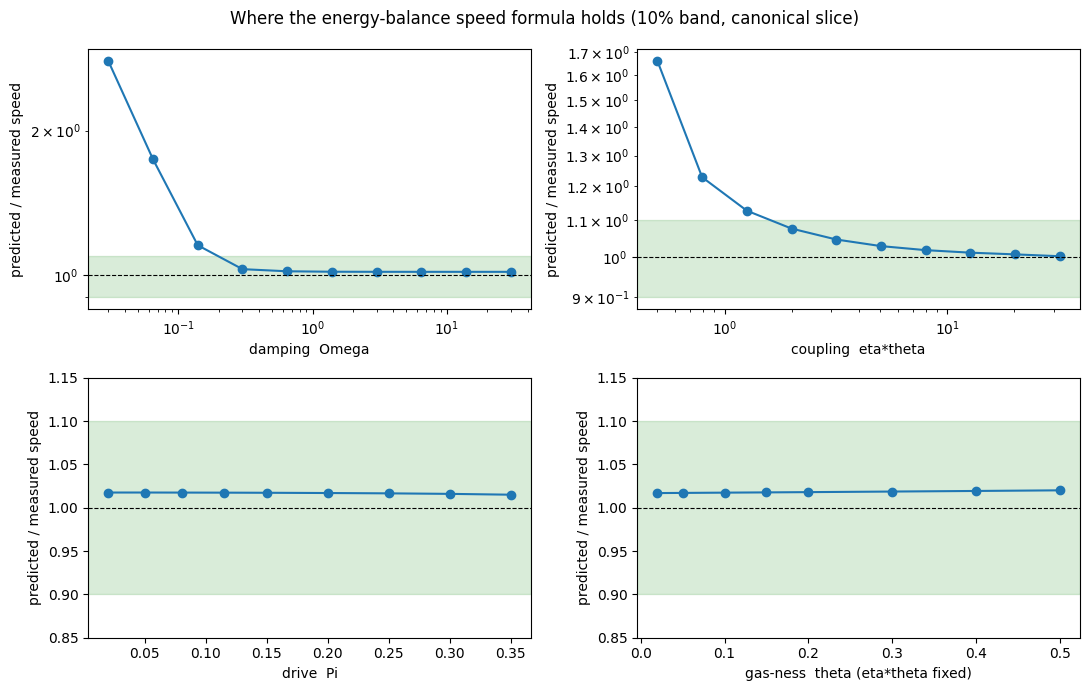

Omega:     within 10% for Omega >~ 0.20
eta*theta: within 10% for eta*theta >~ 1.6  (front ~ 1.8 sites wide at the edge)
Pi:        worst error 1.7%
theta:     worst error 2.0%


In [12]:
# One sweep per group, others at canonical (eta*theta=8, theta=0.1, Pi=0.115, Omega=10).
# Run times are matched to each wave's speed so the front crosses enough lattice
# for a clean fit; the underdamped sweep gets a longer lattice (fast fronts).

def arrieta_ratio(res, Pi_v, Omega_v):
    """Predicted / measured speed; prediction from the mid-run front profile."""
    snap = res['frames'][len(res['frames'])//2]
    integral = np.sum(np.gradient(snap)**2)
    psi = lambda u: u**4/4 - u**2/2 + Pi_v*u
    v_pred = (psi(res['u_hi']) - psi(res['u_lo'])) / (Omega_v * integral)
    return v_pred / res['speed']

def measure(eta_v, theta_v, Pi_v, Omega_v, T, N=150):
    res = run(eta_v, theta_v, Pi_v, Omega_v, N=N, T=T, save_every=200)
    if 'error' in res or not np.isfinite(res.get('speed', np.nan)) or res['speed'] < 1e-4:
        return np.nan
    return arrieta_ratio(res, Pi_v, Omega_v)

Om_vals = np.geomspace(0.03, 30, 10)
r_Om = [measure(eta, theta, Pi, Om, T=(100.0 if Om < 1 else min(40.0*Om, 1200.0)), N=300)
        for Om in Om_vals]

et_vals = np.geomspace(0.5, 32, 10)
r_et = [measure(et/theta, theta, Pi, Omega, T=float(np.clip(1200/np.sqrt(et), 150, 1800)))
        for et in et_vals]

Pi_vals = np.array([0.02, 0.05, 0.08, 0.115, 0.15, 0.20, 0.25, 0.30, 0.35])
r_Pi = [measure(eta, theta, p, Omega, T=float(np.clip(58/p, 200, 1500))) for p in Pi_vals]

th_vals = np.array([0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])
r_th = [measure(8/t, t, Pi, Omega, T=500.0) for t in th_vals]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [(axes[0,0], Om_vals, r_Om, 'damping  Omega',        'log', 'log'),
          (axes[0,1], et_vals, r_et, 'coupling  eta*theta',   'log', 'log'),
          (axes[1,0], Pi_vals, r_Pi, 'drive  Pi',             'linear', 'linear'),
          (axes[1,1], th_vals, r_th, 'gas-ness  theta (eta*theta fixed)', 'linear', 'linear')]
for ax, x, r, lab, xs, ys in panels:
    ax.axhspan(0.9, 1.1, color='green', alpha=0.15, label='within 10%')
    ax.plot(x, r, 'o-')
    ax.axhline(1.0, color='k', lw=0.8, ls='--')
    ax.set_xscale(xs); ax.set_yscale(ys)
    ax.set_xlabel(lab); ax.set_ylabel('predicted / measured speed')
    if ys == 'linear': ax.set_ylim(0.85, 1.15)
plt.suptitle('Where the energy-balance speed formula holds (10% band, canonical slice)')
plt.tight_layout(); plt.show()

# thresholds: where |ratio - 1| crosses 0.10 (log-interpolated on the swept axis)
def threshold(x, r):
    x, r = np.asarray(x, float), np.asarray(r, float)
    for i in range(len(x) - 1):
        a, b = abs(r[i]-1) - 0.1, abs(r[i+1]-1) - 0.1
        if a > 0 >= b:
            f = a / (a - b)
            return float(np.exp(np.log(x[i]) + f*(np.log(x[i+1]) - np.log(x[i]))))
    return np.nan

Om_thr, et_thr = threshold(Om_vals, r_Om), threshold(et_vals, r_et)
print(f"Omega:     within 10% for Omega >~ {Om_thr:.2f}")
print(f"eta*theta: within 10% for eta*theta >~ {et_thr:.1f}  "
      f"(front ~ {np.sqrt(2*et_thr):.1f} sites wide at the edge)")
print(f"Pi:        worst error {100*max(abs(r-1) for r in r_Pi):.1f}%")
print(f"theta:     worst error {100*max(abs(r-1) for r in r_th):.1f}%")

## A check: the gas is not just a spring

Everything above depends on $\eta$ and $\theta$ only through their product - which is
what a plain spring chain would give. A final check asks whether the gas ever
does more than a spring. A wave can pass in two mirrored ways: one squeezes the
gas pockets as it goes, the other stretches them. For spring coupling the two
are exact mirror images, so their speeds are identical. Boyle's law is lopsided
- squeezing a pocket raises its pressure by more than stretching lowers it - so
for the gas a small gap is expected, growing with $\theta$ and vanishing in the
$\theta \to 0$ spring limit.

The comparison below holds $\eta \, \theta$ fixed and turns up $\theta$ alone. (The
mirrored wave = flip the sign of $\Pi$ and start from the opposite state.) The gap
is real but stays small over this notebook's range which is a consistency check on
what $\theta$ means.

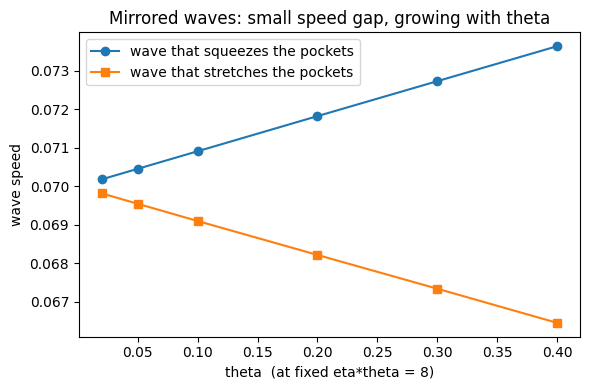

theta   squeeze   stretch   gap
0.02    0.0702    0.0698   +0.5%
0.05    0.0705    0.0695   +1.3%
0.10    0.0709    0.0691   +2.6%
0.20    0.0718    0.0682   +5.3%
0.30    0.0727    0.0673   +8.0%
0.40    0.0736    0.0665   +10.8%


In [9]:
kap = 8.0                                              # eta*theta held fixed
th_vals   = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4]
c_stretch = [run(kap/t, t, +Pi, Omega, N=150, T=120)['speed'] for t in th_vals]
c_squeeze = [run(kap/t, t, -Pi, Omega, N=150, T=120, flip=True)['speed'] for t in th_vals]

plt.figure(figsize=(6, 4))
plt.plot(th_vals, c_squeeze, 'o-', label='wave that squeezes the pockets')
plt.plot(th_vals, c_stretch, 's-', label='wave that stretches the pockets')
plt.xlabel('theta  (at fixed eta*theta = 8)'); plt.ylabel('wave speed')
plt.title('Mirrored waves: small speed gap, growing with theta')
plt.legend(); plt.tight_layout(); plt.show()

print("theta   squeeze   stretch   gap")
for t, cq, cs in zip(th_vals, c_squeeze, c_stretch):
    print(f"{t:.2f}    {cq:.4f}    {cs:.4f}   {100*(cq-cs)/cs:+.1f}%")

## Summary

Working in the four groups instead of the eight raw parameters bought five things:

1. **One model, every build** - any two physical systems with the same $\eta, \theta, \Pi, \Omega$
   produce the same wave – as expected.
2. **Fewer experiments** - one-knob sweeps of $p_0, V_0 \, \text{and} \, A$ all trace the same
   curve against the single product $\eta \, \theta$; one dimensionless sweep replaces them all.
3. **A width law** - the front width grows as the square root of the single product $\eta \, \theta$,
   which stands in for five raw knobs.
4. **A validity map for the speed formula** - within 10% once safely overdamped
   ($\Omega$ above $\sim 0.2$ at this slice), tolerating drive to the spinodal, fronts a
   couple of diaphragms wide, and any $\theta$: damping is the master dial.
5. **A gas-vs-spring check** - waves that squeeze the pockets run slightly faster
   than their stretching mirror image; a spring chain gives exactly zero gap. The
   difference grows with $\theta$ and stays small over this notebook's range.

(The dimensional groundwork - the integrator checks, the Arrieta formula's validity region,
and the ringing physics - is in `diaphragm_metafluid.ipynb`.)